In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

This section imports the required libraries for model evaluation and visualization. Pandas and NumPy are used for data handling and numerical operations, while Scikit-learn metrics are used to evaluate model performance using accuracy, classification report, and confusion matrix. Matplotlib and Seaborn are imported for creating evaluation visualizations, and Joblib is used for loading the saved machine learning model.

In [2]:
df = pd.read_csv("../data/cleaned_data.csv")

3. Load Saved Model

In [5]:
import os

print(os.listdir("../models"))

['random_forest_model.pkl']


This step checks the contents of the models folder using the os library. It helps verify that important files such as the trained model, preprocessing pipeline, and metadata file have been successfully saved.

4. Prepare Data

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop("Purchase_Intent", axis=1)

y = df["Purchase_Intent"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

C:\Users\hp\AppData\Local\Temp\ipykernel_13196\2963917884.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


This step prepares the dataset for model evaluation. Categorical variables are converted into numerical values using Label Encoding, the dataset is divided into features (X) and target variable (y), feature scaling is applied using StandardScaler, and the data is split into training and testing sets. These preprocessing steps ensure that the evaluation process uses properly formatted and standardized data.

In [10]:
import joblib

best_model = joblib.load(
    "../models/random_forest_model.pkl"
)

This step loads the previously saved Random Forest machine learning model using joblib. Loading the saved model allows it to be reused for prediction and evaluation without retraining the model again.

5. Prediction

In [11]:
best_pred = best_model.predict(X_test)

This step uses the loaded Random Forest model to generate predictions on the testing dataset. The predicted values are stored in the variable best_pred and will be used for evaluating model performance.

6. Accuracy

In [12]:
accuracy = accuracy_score(y_test, best_pred)

print("Accuracy:", accuracy)

Accuracy: 0.31


This step calculates the accuracy score of the trained model. Accuracy measures the percentage of correct predictions made by the model on the testing dataset and provides a basic evaluation of overall model performance.

7. Classification Report

In [13]:
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.38      0.38      0.38        52
           1       0.27      0.43      0.33        46
           2       0.28      0.15      0.19        54
           3       0.32      0.29      0.30        48

    accuracy                           0.31       200
   macro avg       0.31      0.31      0.30       200
weighted avg       0.31      0.31      0.30       200



This step generates a classification report to evaluate the performance of the machine learning model. The report includes important evaluation metrics such as precision, recall, F1-score, and support for each class, providing a detailed analysis of model performance.

8. Confusion Matrix

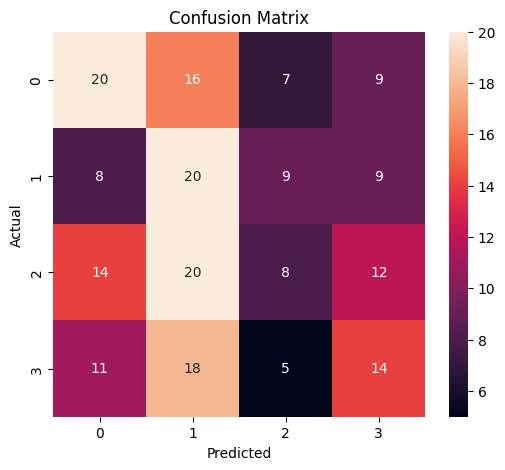

In [14]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

This step creates and visualizes the confusion matrix for the machine learning model. The confusion matrix compares actual values with predicted values, helping to identify correct predictions and classification errors. A heatmap is used to provide a clear visual representation of model performance.

9.Model Comparison

In [15]:
models_results = {
    "Random Forest": accuracy_score(y_test, best_pred)
}

print(models_results)

{'Random Forest': 0.31}


This step stores the evaluation accuracy of the Random Forest model in a dictionary for model comparison. Model comparison helps identify the best-performing algorithm based on evaluation metrics such as accuracy.

10. ROC Curve

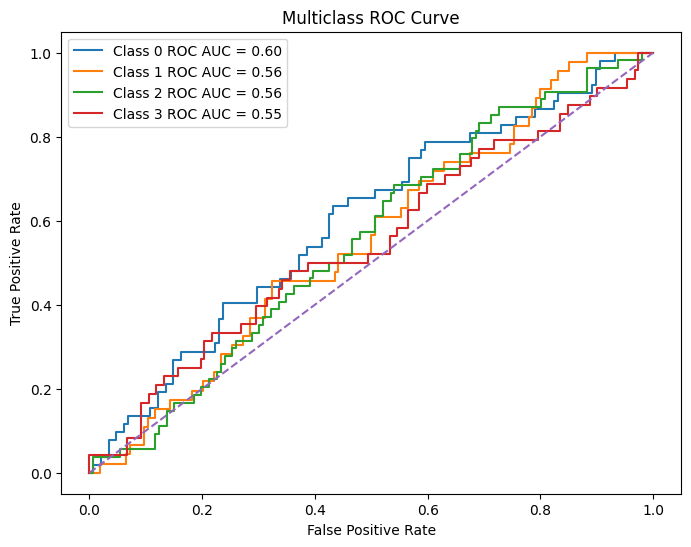

In [17]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get class labels
classes = np.unique(y_test)

# Binarize y_test for multiclass ROC
y_test_bin = label_binarize(y_test, classes=classes)

# Get prediction probabilities
y_prob = best_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {classes[i]} ROC AUC = {roc_auc:.2f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()

This step creates a multiclass ROC (Receiver Operating Characteristic) curve for evaluating the performance of the Random Forest model. The target variable is first converted into binary format for each class using label_binarize(). Prediction probabilities are then generated using predict_proba(), and ROC curves are plotted for each class. The Area Under the Curve (AUC) is calculated to measure the model’s ability to distinguish between classes.

11. Precision-Recall Curve

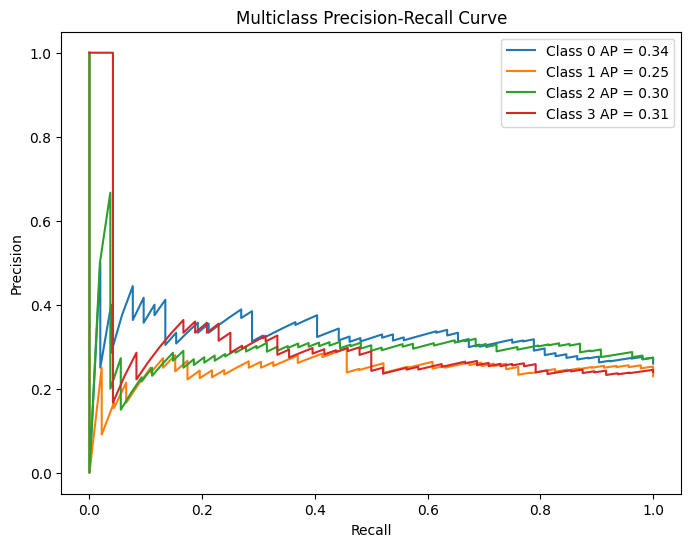

In [19]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Get class labels
classes = np.unique(y_test)

# Convert y_test to binary format for each class
y_test_bin = label_binarize(y_test, classes=classes)

# Get predicted probabilities
y_prob = best_model.predict_proba(X_test)

# Plot Precision-Recall curve for each class
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    precision, recall, thresholds = precision_recall_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    avg_precision = average_precision_score(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f"Class {classes[i]} AP = {avg_precision:.2f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision-Recall Curve")
plt.legend()
plt.show()

This step creates a multiclass Precision-Recall curve to evaluate the classification performance of the Random Forest model. The target variable is converted into binary format for each class using label_binarize(), and prediction probabilities are generated using predict_proba(). Precision and recall values are calculated for each class, and the Average Precision (AP) score is used to summarize model performance.

12. Error Analysis

In [21]:
# Error Analysis

errors = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_pred
})

wrong_predictions = errors[
    errors["Actual"] != errors["Predicted"]
]

wrong_predictions.head()

,Actual,Predicted
1,2,0
2,2,1
3,1,2
4,1,0
6,2,0


This step performs error analysis by comparing the actual values with the predicted values generated by the model. Misclassified records are identified and stored in a separate dataframe called wrong_predictions. Error analysis helps understand where the model makes incorrect predictions and provides insights for future model improvement.

In [22]:
wrong_predictions.shape

(138, 2)

This step checks the number of misclassified records identified during error analysis. The shape() function returns the total number of incorrect predictions and helps evaluate how many classification errors were made by the model.

In [23]:
error_rate = len(wrong_predictions) / len(errors)

print("Error Rate:", error_rate)

Error Rate: 0.69


This step calculates the error rate of the machine learning model. The error rate represents the proportion of incorrect predictions compared to the total number of predictions made on the testing dataset. A lower error rate indicates better model performance.

13. Feature Importance

In [24]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
0,Customer_ID,0.074455
7,Location,0.070874
9,Purchase_Amount,0.069265
22,Time_of_Purchase,0.068546
27,Spending_Per_Age,0.066789
8,Purchase_Category,0.056176
1,Age,0.053496
26,Time_to_Decision,0.047628
10,Frequency_of_Purchase,0.045563
18,Customer_Satisfaction,0.045321


This step analyzes feature importance for the Random Forest model. Feature importance measures how much each feature contributes to the model’s predictions. The features are sorted in descending order to identify the most influential variables affecting customer purchase intention.

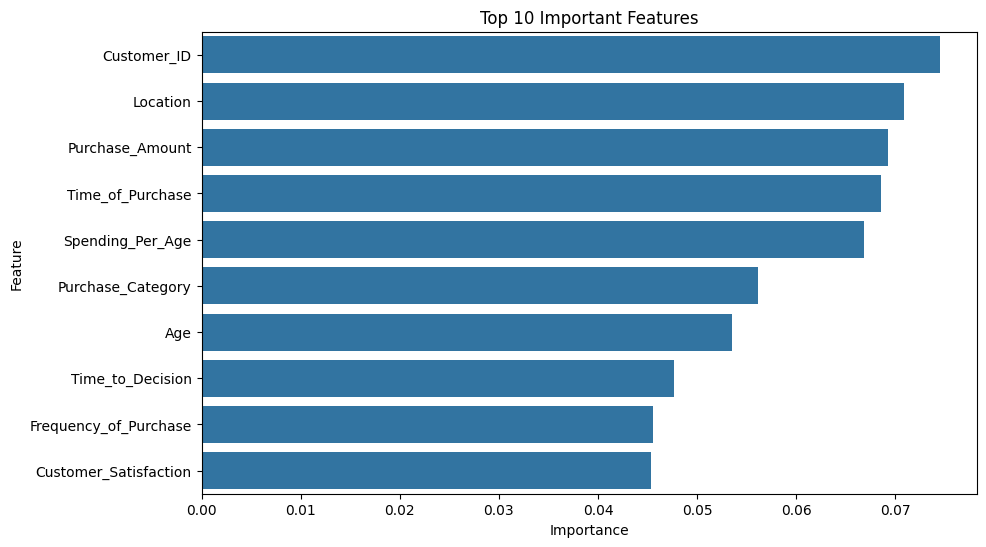

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

This step visualizes the top 10 most important features identified by the Random Forest model using a bar plot. The graph helps interpret which variables have the greatest influence on customer purchase intention predictions.

In [27]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    best_pred
)

with open(
    "../reports/evaluation_results/classification_report.txt",
    "w"
) as f:
    
    f.write(report)

print("Classification report saved")

Classification report saved


This step generates a classification report and saves it as a text file inside the evaluation_results folder. The report includes important evaluation metrics such as precision, recall, F1-score, and support for each class. Saving the report allows the evaluation results to be documented and reused later for analysis and reporting.

In [28]:
with open(
    "../reports/evaluation_results/model_accuracy.txt",
    "w"
) as f:
    
    f.write(str(accuracy))

print("Accuracy saved")

Accuracy saved


This step saves the model accuracy score into a text file inside the evaluation_results folder. Saving the accuracy result helps document the final performance of the machine learning model for future reference and reporting.

In [29]:
with open(
    "../reports/evaluation_results/error_rate.txt",
    "w"
) as f:
    
    f.write(str(error_rate))

print("Error rate saved")

Error rate saved


This step saves the model error rate into a text file inside the evaluation_results folder. The error rate represents the proportion of incorrect predictions made by the model and is stored for documentation and future analysis purposes.

In [30]:
importance.to_csv(
    "../reports/evaluation_results/feature_importance.csv",
    index=False
)

print("Feature importance saved")

Feature importance saved


This step saves the feature importance analysis results into a CSV file inside the evaluation_results folder. The saved file contains feature names and their corresponding importance scores, which can be used later for reporting, visualization, and interpretation of the model.